# 실습 7: 이미지 분류 & 캡셔닝 on Databricks

**목표**: 사전학습된 Vision Transformer(ViT)로 이미지를 분류하고, Foundation Model API로 이미지 캡셔닝(설명 생성)을 수행합니다.

**배울 것**:
- Part A: HuggingFace ViT 모델로 이미지 분류 (Transfer Learning)
- Part B: Databricks Foundation Model API로 이미지 캡셔닝 (멀티모달 LLM)
- Part C: 분류 + 캡셔닝 파이프라인을 MLflow로 추적

**소요 시간**: ~50분

---

### 💡 핵심 개념

| 개념 | 설명 |
|------|------|
| **Vision Transformer (ViT)** | 이미지를 패치(조각)로 나눠 Transformer로 처리하는 모델 |
| **Transfer Learning** | 사전학습된 모델을 새 작업에 재활용하는 기법 |
| **이미지 캡셔닝** | 이미지를 보고 자연어 설명을 생성하는 작업 |
| **멀티모달 LLM** | 텍스트 + 이미지를 동시에 이해하는 대규모 언어 모델 |

## 🔧 환경 설정

In [0]:
# 필요한 패키지 설치
# 설치 후 Python 재시작이 필요합니다!
%pip install transformers torch torchvision datasets pillow --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# ⚠️ pip install 후 반드시 실행!
# Python 재시작 후 아래 셀의 변수들이 초기화되므로, 이 셀 이후부터 다시 실행하세요.
dbutils.library.restartPython()

In [0]:
# 공통 설정 — Python 재시작 후 이 셀부터 실행!
CATALOG = "3dt005_databricks"
SCHEMA = "food"

print(f"📌 카탈로그: {CATALOG}")
print(f"📌 스키마: {SCHEMA}")

📌 카탈로그: 3dt005_databricks
📌 스키마: food


---
## Part A: 이미지 분류 — Vision Transformer (ViT)

### 📖 ViT(Vision Transformer)란?

기존 이미지 분류는 CNN(합성곱 신경망)이 주류였지만, 2020년 Google이 발표한 ViT는
NLP에서 성공한 Transformer 구조를 이미지에 적용했습니다.

**작동 원리:**
1. 이미지를 16×16 픽셀 **패치**로 분할 (예: 224×224 이미지 → 196개 패치)
2. 각 패치를 벡터로 변환 (**패치 임베딩**)
3. 위치 정보 추가 (**포지셔널 인코딩**)
4. Transformer 인코더로 패치 간 관계 학습
5. [CLS] 토큰으로 전체 이미지 분류

**장점**: 대규모 데이터에서 CNN보다 뛰어난 성능, Transfer Learning에 탁월

### Step A-1: 데이터 준비 — 음식 이미지 다운로드

In [0]:
from datasets import load_dataset
import matplotlib.pyplot as plt
from PIL import Image

# HuggingFace에서 음식 분류 데이터셋 로드
# Food-101에서 5개 클래스만 사용 (비용 절약)
import os
os.environ["HF_DATASETS_CACHE"] = "/tmp/hf_cache"
os.environ["HF_HOME"] = "/tmp/hf_home"

dataset = load_dataset(
    "ethz/food101",
    split="train",
    trust_remote_code=True,
    cache_dir="/tmp/hf_cache"
)

# 5개 음식 카테고리만 선택
target_foods = ["pizza", "sushi", "fried_rice", "ramen", "ice_cream"]
target_labels = {name: idx for idx, name in enumerate(dataset.features["label"].names) if name in target_foods}

print(f"✅ 선택한 음식 카테고리:")
for name, label_id in target_labels.items():
    print(f"   - {name} (label: {label_id})")

/databricks/python_shell/lib/dbruntime/huggingface_patches/datasets.py:45: UserWarning: The cache_dir for this dataset is /tmp/hf_cache, which is not a persistent path.Therefore, if/when the cluster restarts, the downloaded dataset will be lost.The persistent storage options for this workspace/cluster config are: [DBFS, UC Volumes].Please update either `cache_dir` or the environment variable `HF_DATASETS_CACHE`to be under one of the following root directories: ['/dbfs/', '/Volumes/']
  warnings.warn(warning_message)
/databricks/python_shell/lib/dbruntime/huggingface_patches/datasets.py:14: UserWarning: During large dataset downloads, there could be multiple progress bar widgets that can cause performance issues for your notebook or browser. To avoid these issues, use `datasets.utils.logging.disable_progress_bar()` to turn off the progress bars.
  warnings.warn(


Generating train split:   0%|          | 0/75750 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/25250 [00:00<?, ? examples/s]

✅ 선택한 음식 카테고리:
   - fried_rice (label: 44)
   - ice_cream (label: 58)
   - pizza (label: 76)
   - ramen (label: 81)
   - sushi (label: 95)


In [0]:
# 선택한 카테고리의 이미지만 필터링 (카테고리당 50장 = 총 250장)
import random
random.seed(42)

label_ids = set(target_labels.values())
filtered_data = {"image": [], "label": [], "label_name": []}

# 카테고리별로 이미지 수집
label_to_name = {v: k for k, v in target_labels.items()}
counts = {label_id: 0 for label_id in label_ids}
MAX_PER_CLASS = 50

for item in dataset:
    label = item["label"]
    if label in label_ids and counts[label] < MAX_PER_CLASS:
        filtered_data["image"].append(item["image"])
        filtered_data["label"].append(label)
        filtered_data["label_name"].append(label_to_name[label])
        counts[label] += 1
    if all(c >= MAX_PER_CLASS for c in counts.values()):
        break

print(f"\n✅ 총 {len(filtered_data['image'])}장 이미지 준비 완료!")
for name, label_id in target_labels.items():
    print(f"   {name}: {counts[label_id]}장")

/databricks/python/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:858: UserWarning: Truncated File Read
  warnings.warn(str(msg))



✅ 총 250장 이미지 준비 완료!
   fried_rice: 50장
   ice_cream: 50장
   pizza: 50장
   ramen: 50장
   sushi: 50장


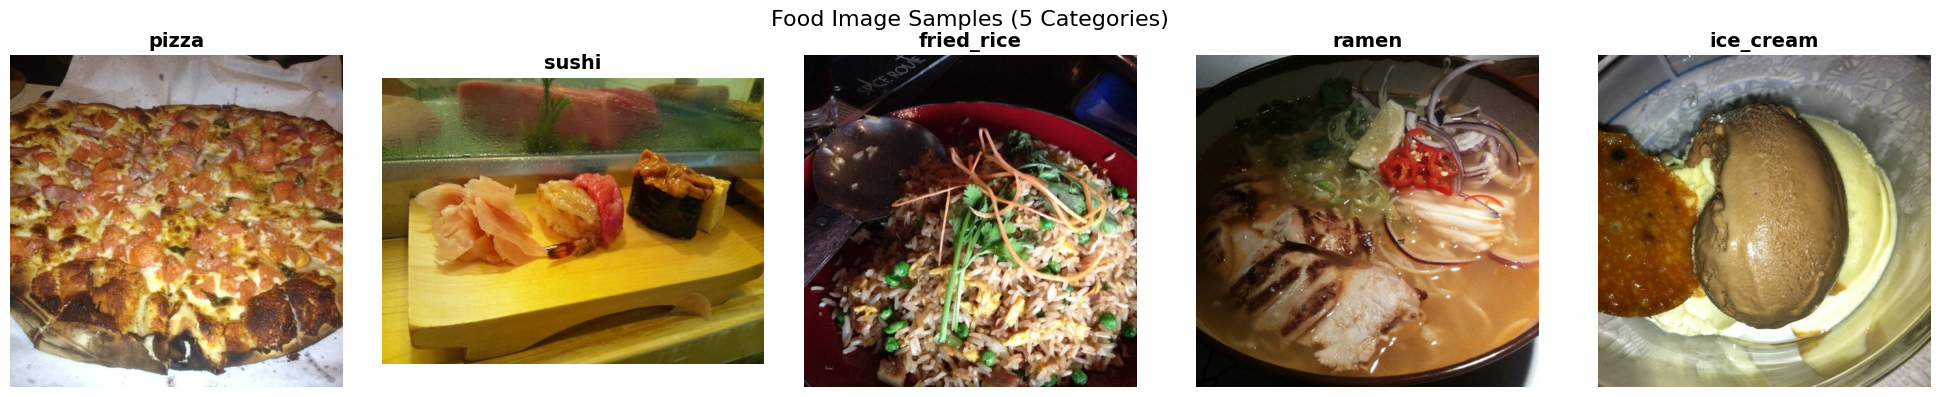

In [0]:
# 📸 샘플 이미지 시각화
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, name in enumerate(target_foods):
    # 해당 카테고리의 첫 번째 이미지
    idx = filtered_data["label_name"].index(name)
    axes[i].imshow(filtered_data["image"][idx])
    axes[i].set_title(name, fontsize=14, fontweight="bold")
    axes[i].axis("off")
plt.suptitle("Food Image Samples (5 Categories)", fontsize=16)
plt.tight_layout()
plt.show()

### Step A-2: 사전학습된 ViT 모델 로드

Google의 `vit-base-patch16-224` 모델을 사용합니다.
ImageNet(1000개 클래스)으로 사전학습된 모델입니다.

In [0]:
from transformers import ViTForImageClassification, ViTFeatureExtractor
import torch
import numpy as np

# 사전학습된 ViT 모델 로드 (ImageNet 1000 클래스)
model_name = "google/vit-base-patch16-224"
feature_extractor = ViTFeatureExtractor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(model_name)
model.eval()  # 추론 모드

print(f"✅ ViT 모델 로드 완료: {model_name}")
print(f"   - 모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")
print(f"   - 입력 크기: 224 x 224 픽셀")
print(f"   - 출력 클래스: {model.config.num_labels}개 (ImageNet)")

2026-03-24 08:32:23.343768: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-24 08:32:23.347702: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-24 08:32:23.443999: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-24 08:32:23.836331: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-24 08:32:27.789203: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

/databricks/python/lib/python3.11/site-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

✅ ViT 모델 로드 완료: google/vit-base-patch16-224
   - 모델 파라미터 수: 86,567,656
   - 입력 크기: 224 x 224 픽셀
   - 출력 클래스: 1000개 (ImageNet)


### Step A-3: 이미지 분류 수행

ViT는 ImageNet 1000개 클래스로 학습되었으므로,
음식 이미지도 관련 클래스로 분류할 수 있습니다.

In [0]:
def classify_image(image, top_k=3):
    """이미지를 ViT 모델로 분류하고 상위 k개 결과 반환"""
    # 이미지 전처리 (리사이즈, 정규화)
    inputs = feature_extractor(images=image, return_tensors="pt")

    # 추론 (GPU 불필요)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)

    # 상위 k개 결과
    top_probs, top_indices = torch.topk(probs, top_k)

    results = []
    for prob, idx in zip(top_probs[0], top_indices[0]):
        label = model.config.id2label[idx.item()]
        results.append({"label": label, "confidence": prob.item()})

    return results

# 각 카테고리별 첫 번째 이미지로 분류 테스트
print("🔍 이미지 분류 결과 (Top-3):\n")
for food_name in target_foods:
    idx = filtered_data["label_name"].index(food_name)
    image = filtered_data["image"][idx]
    results = classify_image(image)

    print(f"📷 [{food_name}]")
    for r in results:
        bar = "█" * int(r["confidence"] * 30)
        print(f"   {r['label']:30s} {r['confidence']:.1%} {bar}")
    print()

🔍 이미지 분류 결과 (Top-3):

📷 [pizza]
   pizza, pizza pie               98.0% █████████████████████████████
   plate                          0.2% 
   bakery, bakeshop, bakehouse    0.2% 

📷 [sushi]
   plate                          44.0% █████████████
   hot pot, hotpot                13.8% ████
   tray                           2.4% 

📷 [fried_rice]
   wok                            29.3% ████████
   plate                          9.5% ██
   frying pan, frypan, skillet    7.6% ██

📷 [ramen]
   consomme                       50.7% ███████████████
   hot pot, hotpot                34.8% ██████████
   soup bowl                      7.4% ██

📷 [ice_cream]
   ice cream, icecream            96.3% ████████████████████████████
   chocolate sauce, chocolate syrup 2.6% 
   trifle                         0.5% 



### Step A-4: 배치 분류 — Spark으로 분산 처리

이미지가 수천~수만 장이라면? Spark UDF로 분산 처리합니다.

In [0]:
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, FloatType, ArrayType
import io, base64

# 이미지를 base64로 인코딩하여 Spark DataFrame 생성
rows = []
for i in range(len(filtered_data["image"])):
    img = filtered_data["image"][i]
    # PIL 이미지 → base64 문자열
    buf = io.BytesIO()
    img.save(buf, format="JPEG")
    img_b64 = base64.b64encode(buf.getvalue()).decode("utf-8")
    rows.append((i, filtered_data["label_name"][i], img_b64))

image_df = spark.createDataFrame(rows, ["image_id", "true_label", "image_base64"])
print(f"✅ Spark DataFrame 생성: {image_df.count()}행")
display(image_df.select("image_id", "true_label").limit(10))

✅ Spark DataFrame 생성: 250행


image_id,true_label
0,ramen
1,ramen
2,ramen
3,ramen
4,ramen
5,ramen
6,ramen
7,ramen
8,ramen
9,ramen


### Step A-5: MLflow로 분류 실험 추적

In [0]:
import mlflow

mlflow.set_experiment("/Users/" + spark.sql("SELECT current_user()").first()[0] + "/image_classification_lab")

# 전체 분류 수행 + 정확도 계산
correct = 0
total = len(filtered_data["image"])

# ImageNet 라벨 → 음식 이름 매핑 (근사 매핑)
food_mapping = {
    "pizza": ["pizza", "pizza_pie"],
    "sushi": ["sushi"],
    "fried_rice": ["fried_rice"],
    "ramen": ["ramen", "noodle"],
    "ice_cream": ["ice_cream", "ice_lolly", "chocolate_sauce"]
}

with mlflow.start_run(run_name="vit_food_classification"):
    mlflow.log_param("model_name", model_name)
    mlflow.log_param("num_classes", len(target_foods))
    mlflow.log_param("total_images", total)

    predictions = []
    for i in range(total):
        image = filtered_data["image"][i]
        true_label = filtered_data["label_name"][i]
        result = classify_image(image, top_k=1)
        pred_label = result[0]["label"]
        pred_confidence = result[0]["confidence"]

        # 매핑 체크 (ImageNet 라벨이 음식 이름과 유사한지)
        is_correct = any(
            mapped in pred_label.lower().replace(" ", "_")
            for mapped in food_mapping.get(true_label, [])
        )
        if is_correct:
            correct += 1
        predictions.append({
            "true": true_label,
            "predicted": pred_label,
            "confidence": pred_confidence,
            "correct": is_correct
        })

    accuracy = correct / total
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("total_images", total)
    mlflow.log_metric("correct_predictions", correct)

    print(f"✅ ViT 이미지 분류 완료!")
    print(f"   정확도: {accuracy:.1%} ({correct}/{total})")
    print(f"   * ImageNet 라벨 → 음식 이름 근사 매핑 기준")

2026/03/24 08:32:46 INFO mlflow.tracking.fluent: Experiment with name '/Users/3dt005@msacademy.msai.kr/image_classification_lab' does not exist. Creating a new experiment.


✅ ViT 이미지 분류 완료!
   정확도: 33.6% (84/250)
   * ImageNet 라벨 → 음식 이름 근사 매핑 기준


---
## Part B: 이미지 캡셔닝 — Foundation Model API

### 📖 이미지 캡셔닝이란?

이미지를 보고 자연어로 설명을 생성하는 작업입니다.

**활용 사례:**
- 시각장애인을 위한 이미지 설명 (접근성)
- 이커머스 상품 이미지 자동 태깅
- SNS 자동 캡션 생성
- 의료 영상 소견 자동 작성

**방법:** Databricks Foundation Model API의 멀티모달 LLM을 사용하면
모델 학습 없이 바로 이미지 캡셔닝이 가능합니다!

### Step B-1: Foundation Model API 설정

In [0]:
import base64, io, json
from mlflow.deployments import get_deploy_client

# Databricks Foundation Model API 클라이언트
client = get_deploy_client("databricks")

# 멀티모달 모델 선택 (이미지 + 텍스트 이해 가능)
# Gemma 3 12B: Google의 멀티모달 모델 (가볍고 빠름)
# Claude: Anthropic의 멀티모달 모델 (고품질, 토큰 비용 높음)
VISION_MODEL = "databricks-gemma-3-12b"   # 1순위: 가볍고 비전 지원
# VISION_MODEL = "databricks-claude-sonnet-4"  # 2순위: 고품질 (위가 안 되면 이걸 사용)

print(f"✅ Vision 모델: {VISION_MODEL}")
print("   이미지 + 텍스트를 함께 이해하는 멀티모달 모델입니다.")

✅ Vision 모델: databricks-gemma-3-12b
   이미지 + 텍스트를 함께 이해하는 멀티모달 모델입니다.


### Step B-2: 이미지 캡셔닝 함수 작성

In [0]:
def caption_image(image, prompt="Describe this food image in detail. Include the type of food, its appearance, and likely ingredients."):
    """
    이미지를 Foundation Model API로 캡셔닝

    Parameters:
        image: PIL Image 객체
        prompt: 캡셔닝 프롬프트 (영어 권장 — 한국어 출력이 불안정할 수 있음)

    Returns:
        캡션 텍스트
    """
    # PIL 이미지 → base64 인코딩
    buf = io.BytesIO()
    image.save(buf, format="JPEG")
    img_b64 = base64.b64encode(buf.getvalue()).decode("utf-8")

    # Foundation Model API 호출
    response = client.predict(
        endpoint=VISION_MODEL,
        inputs={
            "messages": [
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "image_url",
                            "image_url": {
                                "url": f"data:image/jpeg;base64,{img_b64}"
                            }
                        },
                        {
                            "type": "text",
                            "text": prompt
                        }
                    ]
                }
            ],
            "max_tokens": 200,
            "temperature": 0.3
        }
    )

    return response["choices"][0]["message"]["content"]

### Step B-3: 음식 이미지 캡셔닝 실행

In [0]:
# 각 카테고리별 1장씩 캡셔닝
print("📝 이미지 캡셔닝 결과:\n")
print("=" * 70)

captions = {}
for food_name in target_foods:
    idx = filtered_data["label_name"].index(food_name)
    image = filtered_data["image"][idx]

    try:
        caption = caption_image(image)
        captions[food_name] = caption
        print(f"\n🍽️ [{food_name}]")
        print(f"   {caption}")
        print("-" * 70)
    except Exception as e:
        print(f"\n⚠️ [{food_name}] 캡셔닝 실패: {e}")
        captions[food_name] = f"Error: {e}"

📝 이미지 캡셔닝 결과:


🍽️ [pizza]
   Here's a detailed description of the food in the image:

**Type of Food:** This is a pizza. Specifically, it appears to be a Neapolitan-style pizza due to its charred crust and simple toppings.

**Appearance:**

*   **Crust:** The crust is thick and puffy, with a distinctly charred and blistered appearance around the edges. It has a rustic, uneven texture, which is characteristic of Neapolitan pizza. There's a significant amount of "leoparding" (dark spots) on the crust, indicating high-heat cooking.
*   **Toppings:** The pizza is generously topped with:
    *   **Cheese:** A creamy, melted cheese (likely mozzarella) forms the base layer.
    *   **Tomatoes:** Bright red, diced tomatoes are scattered across the pizza. They appear fresh and juicy.
    *   **Ham:** Pieces of ham are visible, interspersed with the tomatoes.
    *   **
----------------------------------------------------------------------

🍽️ [sushi]
   Here's a detailed description of the foo

### Step B-4: 다양한 프롬프트로 캡셔닝

In [0]:
# 프롬프트에 따라 캡션이 달라짐!
sample_image = filtered_data["image"][0]
sample_name = filtered_data["label_name"][0]

prompts = {
    "General": "What food is in this image?",
    "Detailed": "Describe this food image in detail including ingredients, cooking style, and likely origin.",
    "Nutritional": "Estimate the nutritional content of this food. List approximate calories, protein, carbs, and fat.",
    "Recipe": "Based on this food image, provide a brief recipe with key ingredients and cooking steps.",
}

print(f"📷 같은 이미지 [{sample_name}], 다른 프롬프트:\n")
for prompt_name, prompt_text in prompts.items():
    try:
        caption = caption_image(sample_image, prompt=prompt_text)
        print(f"💬 [{prompt_name}]")
        print(f"   Prompt: {prompt_text}")
        print(f"   → {caption[:200]}...")
        print()
    except Exception as e:
        print(f"⚠️ [{prompt_name}] 실패: {e}\n")

📷 같은 이미지 [ramen], 다른 프롬프트:

💬 [General]
   Prompt: What food is in this image?
   → Based on the image, this appears to be a bowl of **Ramen**. 

Here's a breakdown of what I can identify:

*   **Noodles:** The long, white strands are ramen noodles.
*   **Broth:** A rich, orange-colo...

💬 [Detailed]
   Prompt: Describe this food image in detail including ingredients, cooking style, and likely origin.
   → Here's a detailed description of the food in the image, including ingredients, cooking style, and likely origin:

**Overall Impression:**

The image showcases a bowl of ramen, a popular Japanese noodl...

💬 [Nutritional]
   Prompt: Estimate the nutritional content of this food. List approximate calories, protein, carbs, and fat.
   → Okay, let's estimate the nutritional content of this ramen dish based on the image. It appears to be a chicken ramen with some visible toppings.  **Please read the important disclaimers at the end of ...

💬 [Recipe]
   Prompt: Based on this food image, p

---
## Part C: 분류 + 캡셔닝 통합 파이프라인

### Step C-1: 통합 분석 — 분류 + 캡셔닝

In [0]:
import mlflow

mlflow.set_experiment("/Users/" + spark.sql("SELECT current_user()").first()[0] + "/image_classification_lab")

# 5장의 대표 이미지에 분류 + 캡셔닝 동시 수행
with mlflow.start_run(run_name="combined_classify_caption"):
    results_table = []

    for food_name in target_foods:
        idx = filtered_data["label_name"].index(food_name)
        image = filtered_data["image"][idx]

        # 1) ViT 분류
        classify_result = classify_image(image, top_k=1)
        predicted = classify_result[0]["label"]
        confidence = classify_result[0]["confidence"]

        # 2) Foundation Model 캡셔닝
        try:
            caption = caption_image(image)
        except:
            caption = "(캡셔닝 실패)"

        results_table.append({
            "food": food_name,
            "vit_prediction": predicted,
            "confidence": f"{confidence:.1%}",
            "caption": caption[:100] + "..."
        })

        print(f"✅ {food_name}: {predicted} ({confidence:.1%})")

    # MLflow에 결과 기록
    mlflow.log_param("pipeline", "classify + caption")
    mlflow.log_param("classifier", "google/vit-base-patch16-224")
    mlflow.log_param("captioner", VISION_MODEL)

✅ pizza: pizza, pizza pie (98.0%)
✅ sushi: plate (44.0%)
✅ fried_rice: wok (29.3%)
✅ ramen: consomme (50.7%)
✅ ice_cream: ice cream, icecream (96.3%)


In [0]:
# 결과를 Spark DataFrame으로 표시
import pandas as pd

results_pdf = pd.DataFrame(results_table)
results_df = spark.createDataFrame(results_pdf)
display(results_df)

food,vit_prediction,confidence,caption
pizza,"pizza, pizza pie",98.0%,Here's a detailed description of the food image: **Type of Food:** The image shows a pizza. **Appe...
sushi,plate,44.0%,Here's a detailed description of the food in the image: **Type of Food:** This is a presentation of...
fried_rice,wok,29.3%,Here's a detailed description of the food in the image: **Type of Food:** The dish appears to be f...
ramen,consomme,50.7%,"Here's a detailed description of the food in the image: **Type of Food:** This is a bowl of ramen,..."
ice_cream,"ice cream, icecream",96.3%,Here's a detailed description of the food in the image: **Type of Food:** This appears to be a dess...


### Step C-2: 결과를 Delta 테이블로 저장

In [0]:
# 분석 결과 저장
results_df.write.mode("overwrite").saveAsTable(
    f"{CATALOG}.{SCHEMA}.image_analysis_results_lab"
)

print(f"✅ 분석 결과 저장 완료: {CATALOG}.{SCHEMA}.image_analysis_results_lab")

✅ 분석 결과 저장 완료: 3dt005_databricks.food.image_analysis_results_lab


In [0]:
%sql
-- 저장된 결과 확인
SELECT * FROM `3dt005_databricks`.food.image_analysis_results_lab;

food,vit_prediction,confidence,caption
pizza,"pizza, pizza pie",98.0%,Here's a detailed description of the food image: **Type of Food:** The image shows a pizza. **Appe...
sushi,plate,44.0%,Here's a detailed description of the food in the image: **Type of Food:** This is a presentation of...
fried_rice,wok,29.3%,Here's a detailed description of the food in the image: **Type of Food:** The dish appears to be f...
ramen,consomme,50.7%,"Here's a detailed description of the food in the image: **Type of Food:** This is a bowl of ramen,..."
ice_cream,"ice cream, icecream",96.3%,Here's a detailed description of the food in the image: **Type of Food:** This appears to be a dess...


## 🎯 핵심 정리

| 방법 | 모델 | 용도 | GPU 필요? | 비용 |
|------|------|------|-----------|------|
| **ViT 분류** | `google/vit-base-patch16-224` | 이미지 → 카테고리 | ❌ CPU OK | 무료 (오픈소스) |
| **Foundation Model 캡셔닝** | 멀티모달 LLM | 이미지 → 텍스트 설명 | ❌ API 호출 | 토큰당 과금 |
| **통합 파이프라인** | ViT + LLM | 분류 + 설명 자동화 | ❌ | 최소 비용 |

### 💡 배운 것
- **Transfer Learning**: 사전학습된 ViT 모델로 학습 없이 이미지 분류
- **멀티모달 API**: Foundation Model API로 이미지 캡셔닝 (코드 몇 줄!)
- **프롬프트 엔지니어링**: 같은 이미지라도 프롬프트에 따라 다른 분석 가능
- **MLflow 추적**: 이미지 분석 실험도 MLflow로 재현 가능하게 관리

### 🔥 실무 활용 아이디어
- **이커머스**: 상품 이미지 자동 분류 + 설명 생성
- **의료**: X-ray/CT 스캔 자동 소견 작성
- **제조**: 불량품 이미지 감지 + 결함 설명
- **CCTV**: 객체 감지 + 상황 설명 자동화

---
**실습 완료!** 🎉